In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


polars.config.Config

In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
variant_class = 'intronic'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""verphylop""","""#942c80""","""Vertebrate PhyloP""",1
"""conservation""","""mamphylop""","""#942c80""","""Mammalian PhyloP""",1
"""splicing""","""pangolin_score""","""#28a745""","""Pangolin""",1


In [13]:
plt_df = anno_config_df.group_by(['category', 'color']).agg(pl.len())
plt_df = plt_df.filter(~pl.col('category').is_in(['regulatory', 'regulatory_nondir']))
plt_df

category,color,len
str,str,u64
"""plof""","""#DD4344""",1
"""missense""","""#feb72d""",2
"""splicing""","""#28a745""",4
"""conservation""","""#942c80""",4
"""genetic_diversity""","""#1f77b4""",1


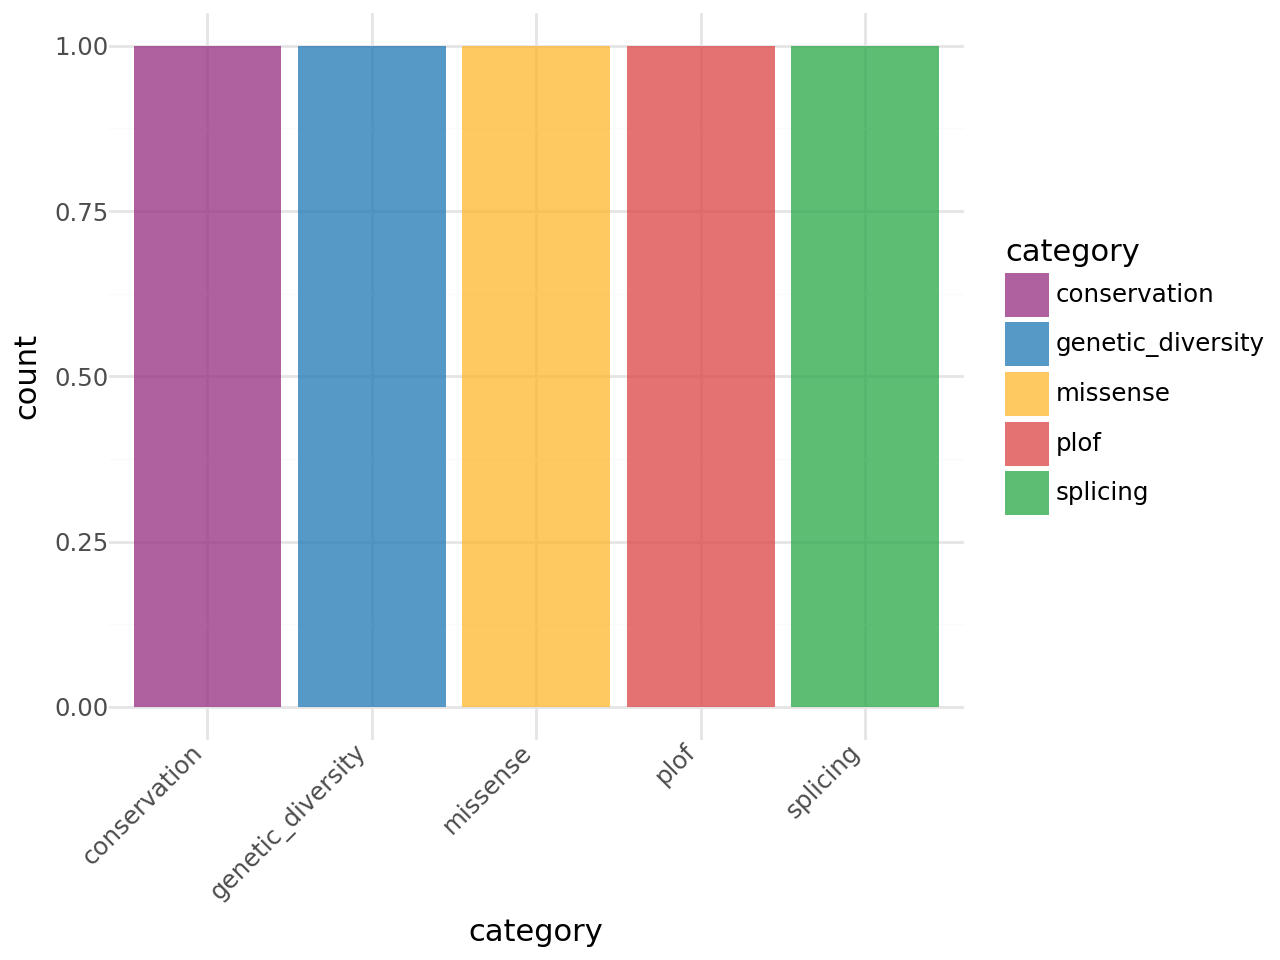

In [14]:

color_dict = dict(zip(plt_df['category'], plt_df['color']))
(
    ggplot(plt_df, aes(x='category', fill='category')) +
    geom_bar(position='dodge', stat='count', alpha=0.75) +
    scale_fill_manual(values=color_dict) +
    theme_minimal() +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
)

In [36]:
# anno = pl.scan_parquet(f"/home/dnanexus/data_dir/variant_classes/genebass1e6_genes_{variant_class.lower()}_variants_annotations.parquet")
# anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

cols = anno.collect_schema().names()
rename_map = {}
for c in cols:
    new = c.lower()
    if new.startswith('cadd_') and (not new.startswith('cadd_raw') and not new.startswith('cadd_phred')):
        new = new[len('cadd_'):]
    rename_map[c] = new

anno = anno.rename(rename_map)
anno.head().collect()

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan,tss,strand,gene_length,gene_name,dist_to_tss,abexp_max,abexp_min,promoterai_abs,promoterai_over,promoterai_under,gpn_star_llr_calibrated_mean
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i64,cat,i64,str,i64,f64,f64,f32,f32,f32,f64
"""chr2""",169197167,"""T""","""G""","""chr2:169197167:T:G""",12335303,"""ENSG00000081479""",0,0.0,0.466688,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,169362534,"""-""",235427,"""LRP2""",165367,0.002291,-0.006063,0.0,0.0,0.0,0.153293
"""chr2""",169204292,"""A""","""T""","""chr2:169204292:A:T""",12338123,"""ENSG00000081479""",0,0.0,0.104863,0.0,0.01,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,169362534,"""-""",235427,"""LRP2""",158242,0.011141,-0.026342,0.0,0.0,0.0,1.684965
"""chr2""",169030531,"""C""","""T""","""chr2:169030531:C:T""",12294336,"""ENSG00000073734""",0,0.0,0.326902,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,169031324,"""-""",115828,"""ABCB11""",793,0.006871,-0.005501,0.0,0.0,0.0,-1.212965
"""chr2""",168910825,"""T""","""G""","""chr2:168910825:T:G""",12247951,"""ENSG00000073734""",4673,0.0,0.554549,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,169031324,"""-""",115828,"""ABCB11""",120499,0.002667,-0.019354,0.0,0.0,0.0,-1.479978
"""chr2""",168969544,"""T""","""C""","""chr2:168969544:T:C""",12270653,"""ENSG00000073734""",0,0.0,1.464585,0.0607,0.02,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,169031324,"""-""",115828,"""ABCB11""",61780,-0.009066,-0.053713,0.0,0.0,0.0,-2.904763


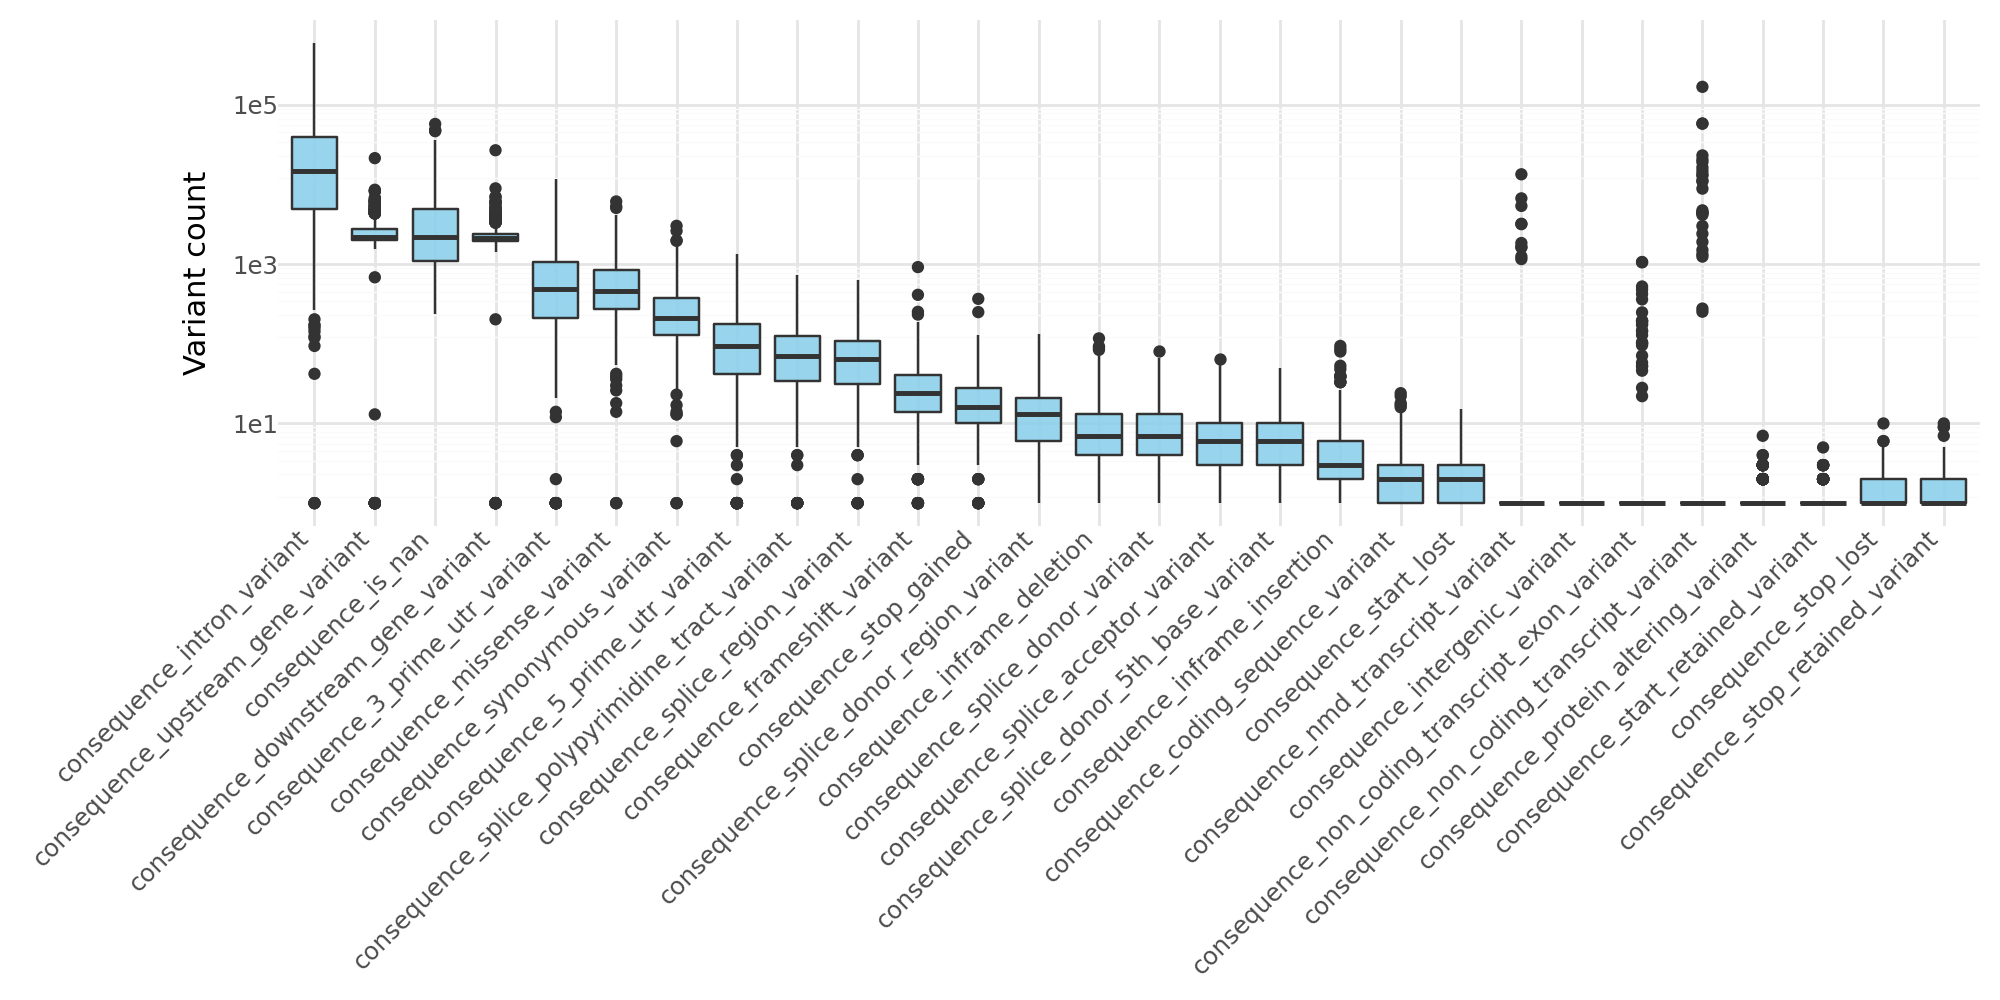

In [37]:
cons_annos = [c for c in anno.collect_schema().names() if c.startswith('consequence_')]

agg_exprs = [pl.col(c).sum() for c in cons_annos]

# Group by 'region' and apply the aggregations
gene_counts = (
    anno.group_by('region')
    .agg(agg_exprs)
    .collect(engine='streaming')
    .unpivot(index='region', variable_name='consequence', value_name='count')
    .with_columns(imputed_count=pl.col('count')+1) # Allows log scale plotting
)

med_counts = (
    gene_counts
    .group_by('consequence')
    .agg(pl.col('imputed_count').median().alias('median_count'))
)

gene_counts = (
    gene_counts
    .join(med_counts, on='consequence', how='left')
    .sort('median_count', descending=True)
    .to_pandas()
)

gene_counts['consequence'] = pd.Categorical(gene_counts['consequence'], categories=gene_counts['consequence'].unique().tolist(), ordered=True)

(
    ggplot(gene_counts, aes(x='consequence', y='imputed_count')) +
    geom_boxplot(fill='skyblue', alpha=0.85) +
    theme_minimal() +
    labs(x='', y='Variant count') +
    scale_x_discrete(limits=gene_counts['consequence'].cat.categories.tolist()) +
    scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)

In [43]:
gpns = anno.select(['id', 'gpn_star_llr_calibrated_mean', 'consequence']).unique().collect().drop_nulls()
gpns

id,gpn_star_llr_calibrated_mean,consequence
str,f64,str
"""chr8:134582249:C:T""",0.388214,"""INTRONIC"""
"""chr3:188233995:C:A""",0.077336,"""INTRONIC"""
"""chr17:4936509:T:C""",-0.011189,"""DOWNSTREAM"""
"""chr1:202551662:G:C""",-0.590556,"""INTRONIC"""
"""chr2:71537075:G:A""",0.453996,"""INTRONIC"""
"""chr19:7272444:C:A""",0.63865,"""INTRONIC"""
"""chr12:124833353:C:T""",0.222663,"""INTRONIC"""
"""chr4:71803223:C:T""",0.340384,"""INTRONIC"""
…,…,…


In [46]:
gpns['consequence'].unique()

consequence
str
"""UPSTREAM"""
"""SPLICE_SITE"""
"""3PRIME_UTR"""
"""SYNONYMOUS"""
"""NONCODING_CHANGE"""
"""5PRIME_UTR"""
"""STOP_GAINED"""
"""INTRONIC"""
"""STOP_LOST"""


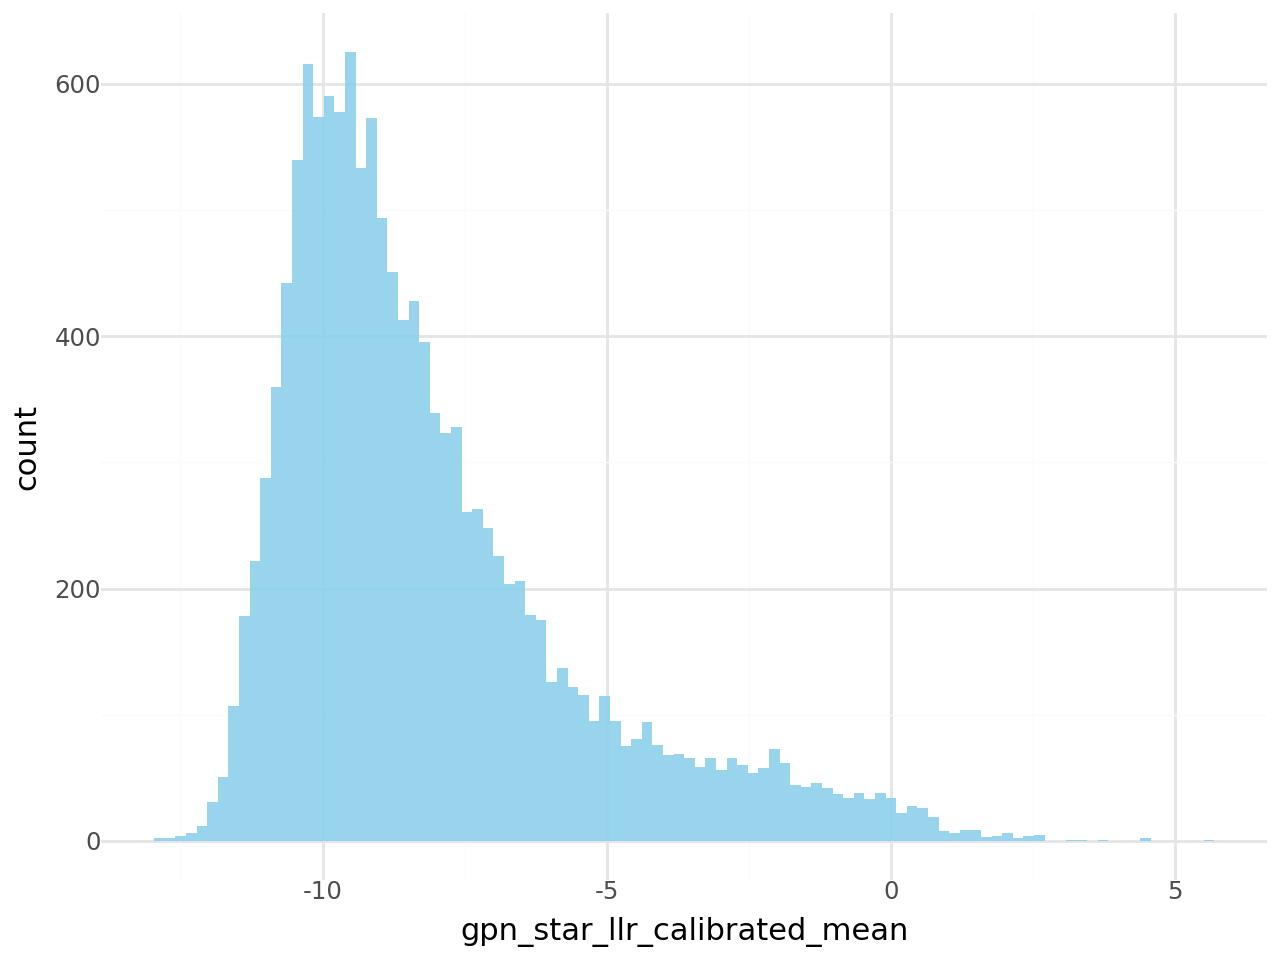

In [47]:
(
    ggplot(gpns.filter(pl.col('consequence')=='STOP_GAINED'), aes(x='gpn_star_llr_calibrated_mean')) +
    geom_histogram(bins=100, fill='skyblue', alpha=0.85) +
    theme_minimal()
)

In [52]:
gpns.filter(pl.col('consequence')=='STOP_GAINED')['gpn_star_llr_calibrated_mean'].median() #.filter(pl.col('gpn_star_llr_calibrated_mean')<-10)

-8.850950064137578

In [53]:
gpns.filter(pl.col('consequence')=='INTRONIC').filter(pl.col('gpn_star_llr_calibrated_mean')<-8.850950064137578)

id,gpn_star_llr_calibrated_mean,consequence
str,f64,str
"""chr2:161998856:A:G""",-9.111513,"""INTRONIC"""
"""chr5:72899914:G:C""",-9.399648,"""INTRONIC"""
"""chr10:100787390:A:T""",-9.836884,"""INTRONIC"""
"""chr10:68673478:C:T""",-9.590391,"""INTRONIC"""
"""chr12:57129138:T:G""",-10.327035,"""INTRONIC"""
"""chr7:117297674:G:T""",-9.790622,"""INTRONIC"""
"""chr16:67194519:G:C""",-9.16418,"""INTRONIC"""
"""chr5:154190925:T:G""",-9.533138,"""INTRONIC"""
…,…,…


# Score distributions across regions

In [38]:
gene_name = "LDLR"
gene_vars = anno.filter(pl.col('gene_name')==gene_name).collect()
gene_vars

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan,tss,strand,gene_length,gene_name,dist_to_tss,abexp_max,abexp_min,promoterai_abs,promoterai_over,promoterai_under,gpn_star_llr_calibrated_mean
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i64,cat,i64,str,i64,f64,f64,f32,f32,f32,f64
"""chr19""",11093738,"""G""","""A""","""chr19:11093738:G:A""",81569835,"""ENSG00000130164""",0,0.0,0.372048,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",4277,-0.005501,-0.005877,0.0,0.0,0.0,-1.285429
"""chr19""",11110949,"""G""","""A""","""chr19:11110949:G:A""",81577106,"""ENSG00000130164""",0,0.0,-0.889739,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",21488,-0.005501,-0.005877,0.0,0.0,0.0,-0.982813
"""chr19""",11137687,"""A""","""C""","""chr19:11137687:A:C""",81588832,"""ENSG00000130164""",3867,0.0,-0.0706,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",48226,0.002469,0.002093,0.0,0.0,0.0,0.213625
"""chr19""",11131908,"""T""","""C""","""chr19:11131908:T:C""",81585996,"""ENSG00000130164""",0,0.0,-0.358473,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",42447,-0.005229,-0.005605,0.0,0.0,0.0,0.589225
"""chr19""",11099670,"""C""","""G""","""chr19:11099670:C:G""",81572185,"""ENSG00000130164""",0,0.0,-0.016461,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",10209,-0.005501,-0.005877,0.0,0.0,0.0,0.865382
"""chr19""",11114441,"""G""","""T""","""chr19:11114441:G:T""",81578659,"""ENSG00000130164""",0,0.0,0.608911,0.0,0.04,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",24980,-0.005303,-0.005679,0.0,0.0,0.0,0.606752
"""chr19""",11136489,"""G""","""C""","""chr19:11136489:G:C""",81588268,"""ENSG00000130164""",2669,0.0,-0.119662,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",47028,0.002469,0.002093,0.0,0.0,0.0,0.190983
"""chr19""",11116843,"""C""","""A""","""chr19:11116

In [39]:
anno_list = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

cons_annos = [c for c in anno.collect_schema().names() if c.startswith('consequence_')]
anno_cons_dist_list = []
for c in cons_annos:
    anno_cons_dist_list.append(
        gene_vars
        .filter(pl.col(c) == 1)
        .select(['chrom', 'pos', 'ref', 'alt', 'id', 'region', 'gene_name'] + anno_list)
        .with_columns(consequence=pl.lit(c))
    )

anno_cons_dist = pl.concat(anno_cons_dist_list).drop_nulls()
anno_cons_dist

chrom,pos,ref,alt,id,region,gene_name,cadd_raw,gpn_score,gpn_star_llr_calibrated_mean,consequence
str,i32,str,str,str,str,str,f32,f32,f64,str
"""chr19""",11131908,"""T""","""C""","""chr19:11131908:T:C""","""ENSG00000130164""","""LDLR""",-0.358473,-1.16,0.589225,"""consequence_3_prime_utr_varian…"
"""chr19""",11133105,"""G""","""A""","""chr19:11133105:G:A""","""ENSG00000130164""","""LDLR""",0.217021,-0.57,0.277947,"""consequence_3_prime_utr_varian…"
"""chr19""",11131891,"""G""","""C""","""chr19:11131891:G:C""","""ENSG00000130164""","""LDLR""",-1.008828,-0.67,-0.097761,"""consequence_3_prime_utr_varian…"
"""chr19""",11132032,"""C""","""A""","""chr19:11132032:C:A""","""ENSG00000130164""","""LDLR""",-0.225037,-1.04,-0.455871,"""consequence_3_prime_utr_varian…"
"""chr19""",11133170,"""C""","""T""","""chr19:11133170:C:T""","""ENSG00000130164""","""LDLR""",0.125201,-0.11,0.408728,"""consequence_3_prime_utr_varian…"
"""chr19""",11133657,"""T""","""G""","""chr19:11133657:T:G""","""ENSG00000130164""","""LDLR""",0.145205,-1.5,0.490264,"""consequence_3_prime_utr_varian…"
"""chr19""",11133617,"""A""","""T""","""chr19:11133617:A:T""","""ENSG00000130164""","""LDLR""",-0.199489,-1.34,0.695824,"""consequence_3_prime_utr_varian…"
"""chr19""",11132770,"""T""","""C""","""chr19:11132770:T:C""","""ENSG00000130164""","""LDLR""",0.422421,-0.81,-0.206447,"""consequence_3_prime_utr_varian…"
…,…,…,…,…,…,…,…,…,…,…


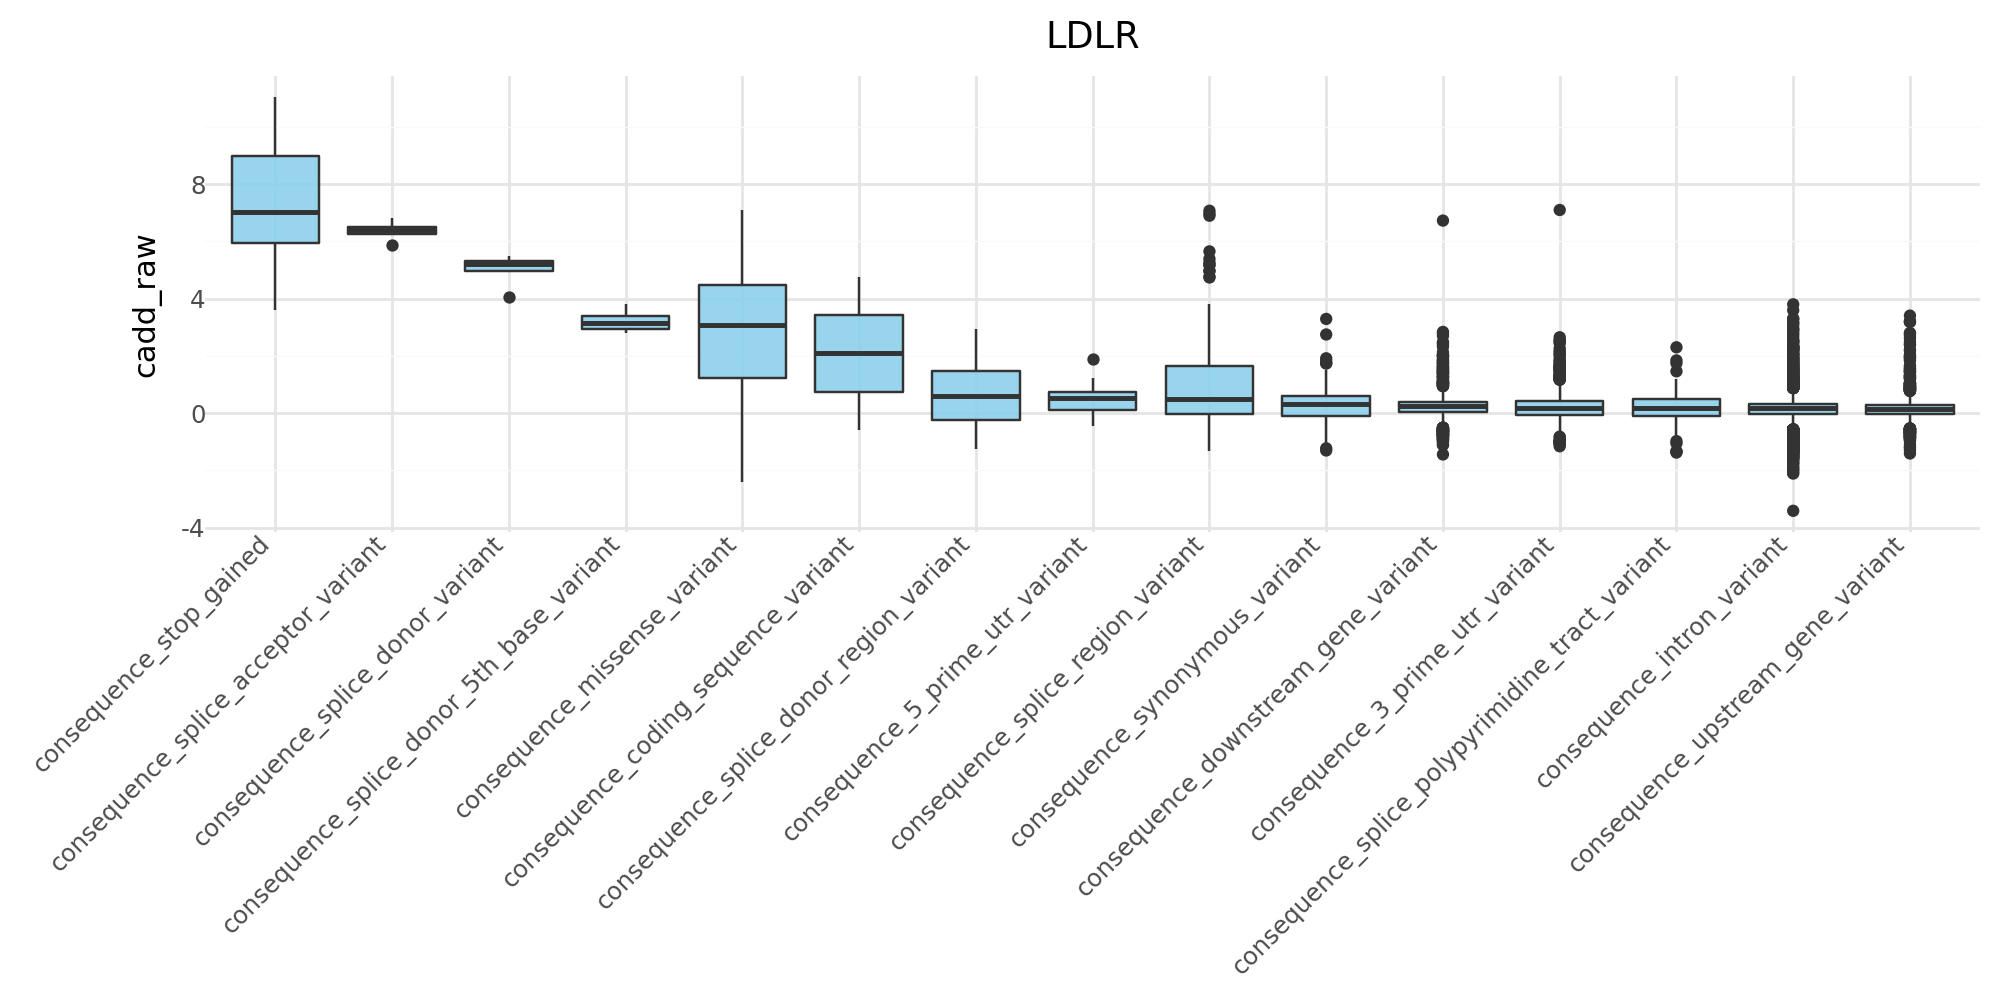

In [32]:
anno2plot = 'cadd_raw'
# anno2plot = 'gpn_score'
# anno2plot = 'gpn_star_llr_calibrated_mean'


med_counts = (
    anno_cons_dist
    .group_by('consequence')
    .agg(pl.col(anno2plot).median().alias(f'median_{anno2plot}'))
)

plot_df = (
    anno_cons_dist
    .join(med_counts, on='consequence', how='left')
    .sort(f'median_{anno2plot}', descending=True)
    .to_pandas()
)

plot_df['consequence'] = pd.Categorical(plot_df['consequence'], categories=plot_df['consequence'].unique().tolist(), ordered=True)

(
    ggplot(plot_df, aes(x='consequence', y=anno2plot)) +
    geom_boxplot(fill='skyblue', alpha=0.85) +
    theme_minimal() +
    labs(
        x='', 
        y=anno2plot,
        title=gene_name,
    ) +
    scale_x_discrete(limits=plot_df['consequence'].cat.categories.tolist()) +
    # scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)

## Olink distribution

In [54]:
ol = pl.read_parquet('/home/dnanexus/data_dir/olink/olink_corrected_rint_90_pcs.parquet')
ol

ENSG00000120053,ENSG00000140443,ENSG00000084674,ENSG00000015475,ENSG00000117748,ENSG00000138760,ENSG00000158481,ENSG00000125977,ENSG00000090534,ENSG00000126581,ENSG00000123146,ENSG00000151892,ENSG00000126088,ENSG00000159167,ENSG00000185245,ENSG00000257727,ENSG00000145623,ENSG00000150093,ENSG00000154734,ENSG00000119681,ENSG00000117090,ENSG00000182512,ENSG00000122194,ENSG00000115008,ENSG00000149131,ENSG00000163531,ENSG00000181754,ENSG00000181449,ENSG00000145703,ENSG00000174827,ENSG00000019186,ENSG00000161944,ENSG00000118762,ENSG00000163281,ENSG00000129116,ENSG00000179364,ENSG00000165699,…,ENSG00000138379,ENSG00000187323,ENSG00000099937,ENSG00000108821,ENSG00000160255,ENSG00000142798,ENSG00000120889,ENSG00000038427,ENSG00000187210,ENSG00000085514,ENSG00000171587,ENSG00000158859,ENSG00000092853,ENSG00000099940,ENSG00000188729,ENSG00000115109,ENSG00000117724,ENSG00000159202,ENSG00000173546,ENSG00000110987,ENSG00000105392,ENSG00000116678,ENSG00000154240,ENSG00000196218,ENSG00000103742,ENSG00000150637,ENSG00000135100,ENSG00000104635,ENSG00000178732,ENSG00000198369,ENSG00000140650,ENSG00000124678,ENSG00000109062,ENSG00000167186,ENSG00000025708,ENSG00000066468,sample
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
-0.592022,2.477856,0.354833,0.036147,1.840019,-0.556804,1.474733,-1.171682,1.107498,-1.338333,0.828315,-1.131312,0.218248,1.565109,0.806431,-1.572063,-1.831415,0.509995,0.259358,0.085273,1.168366,0.92541,1.093288,-0.933884,-0.994071,1.224089,1.267719,1.553798,3.073288,-1.212625,-0.862801,-0.074899,-0.66865,-0.663898,0.097057,-0.381743,1.327905,…,-1.371595,0.00914,1.252964,-0.783421,-0.157359,-1.119737,-0.724983,0.241805,-1.209641,0.36272,0.294487,-0.321351,-0.402962,-0.564039,1.248993,-0.4253,-0.061883,-0.599111,0.85217,0.78783,-1.94696,-0.372829,-0.851819,0.162467,1.08189,1.043062,-0.714187,-0.156151,0.035392,-0.953521,-0.291382,-0.768147,-1.038927,-0.543771,0.47082,0.605257,"""1000107"""
0.061036,-0.530447,null,-1.253191,null,-0.528101,0.789999,0.958858,-2.381235,-0.368299,0.054888,-0.690046,null,-0.826641,2.832754,-0.279628,0.569952,0.119573,null,-0.50122,0.368528,null,1.45478,-1.589655,-0.732112,-0.591059,1.38939,1.887349,0.396136,null,0.518981,null,2.032125,null,null,-0.079974,null,…,0.694591,0.216121,-0.049013,0.284268,-0.54976,0.497791,0.319326,-0.01569,-0.237547,-0.727066,-1.51499,null,1.019035,1.839335,-0.450768,-0.440462,null,null,0.429476,null,-0.450582,0.36664,-0.099686,-0.166322,0.521489,null,0.880101,0.929709,null,null,1.735256,null,null,0.134858,0.403499,-0.595941,"""1001193"""
0.228713,1.297618,-0.425314,-0.576221,0.776633,0.760045,-1.463104,0.835144,0.632535,-0.171881,-0.541161,-1.496928,-0.321374,-0.351952,0.406727,0.924771,1.491036,0.165546,-0.218961,-1.166476,-0.228736,-0.7387,0.381095,-0.332186,0.921432,-0.304638,1.466775,-1.191503,0.417136,-2.490956,1.16585,-1.120534,-0.496822,0.397868,-0.298487,-1.017592,0.02303,…,-0.522438,-0.482936,-0.510518,0.727726,-0.864383,-0.333167,1.521524,-0.421892,0.836682,0.838164,-0.147841,-0.7116,0.001101,-1.098461,-1.235976,-1.553069,1.006304,0.950239,1.110903,0.762993,-0.684849,0.098428,-0.924223,0.349469,-1.095734,0.722191,0.878398,-0.536817,0.851928,-0.044139,0.347408,-0.048799,1.896826,0.68994,-0.900913,1.088444,"""1001694"""
0.674837,null,-1.180707,-1.542909,0.329826,-0.064386,0.062653,0.280349,1.312457,0.735016,1.6472,-1.424351,-0.105581,-0.220363,-0.917835,-0.367986,-0.600775,0.503786,-0.044603,-0.699811,1.099825,-1.655709,1.289587,1.726708,0.703666,-0.784714,-0.043088,0.396061,null,-0.17821,0.791457,-1.485792,-0.954625,-0.054062,0.055513,0.551941,-0.352925,…,1.95272,-0.370944,1.594941,1.06786,-0.164511,-1.338513,2.043463,1.265689,null,1.943549,-0.50395,-0.477835,0.330945,-2.452105,-0.80839,1.28496,-0.787688,-1.115847,-0

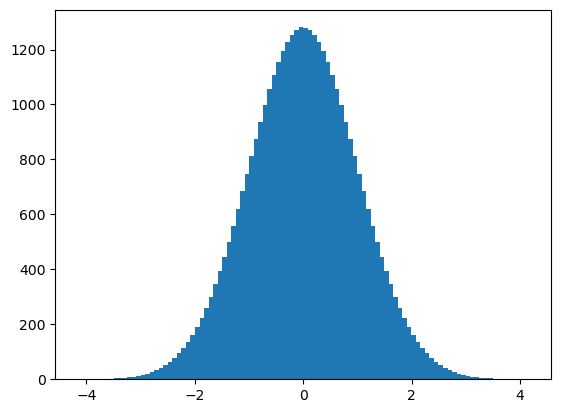

In [58]:
plt.hist(ol['ENSG00000130164'], bins=100)
plt.show()

## RVAT agreement plots

In [10]:
plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).with_columns(
    p_adj_bonf = pl.min_horizontal(pl.col('rvat_pval')*17_500, 1),
).filter(
    (pl.col('trait_type') == 'quantitative') &
    (pl.col('p_adj_bonf') < 0.05)
)

plof

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64
"""PAPPA2""",1,"""ENSG00000116183""",0.000339,357443,-0.195409,0.0365758,28.5431,7.03793,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000116183""",9.1637e-8,0.001604
"""PTPRJ""",11,"""ENSG00000149177""",0.000274,357443,-0.247539,0.0404893,37.3772,9.01164,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000149177""",9.7355e-10,0.000017
"""CNPY2""",12,"""ENSG00000257727""",0.000194,357443,-0.238033,0.0481651,24.4236,6.11174,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000257727""",7.7314e-7,0.01353
"""ACAN""",15,"""ENSG00000157766""",0.000101,357443,-0.436618,0.0667331,42.8076,10.219,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000157766""",6.0395e-11,0.000001
"""IGF1R""",15,"""ENSG00000140443""",0.000081,357443,-0.412619,0.0743493,30.7996,7.54349,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000140443""",2.8609e-8,0.000501
"""G6PC1""",17,"""ENSG00000131482""",0.000904,357443,-0.110167,0.0223225,24.3567,6.09665,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000131482""",8.0048e-7,0.014008
"""MC4R""",18,"""ENSG00000166603""",0.000214,357443,0.255292,0.0457938,31.0786,7.60591,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000166603""",2.4779e-8,0.000434
"""TTN""",2,"""ENSG00000155657""",0.00586,357443,-0.08423,0.008838,90.8354,20.8065,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000155657""",1.5613e-21,2.7324e-17
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…


In [6]:


loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_allvars.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval', 'p_adj_bonf']], on=['region', 'phenotype'], how='inner').with_columns(
    sign_agreement = pl.col('loftee_corr')*pl.col('beta'),
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,p_adj_bonf,sign_agreement,corr_dir
str,str,str,f64,u64,f64,f64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.015696,90243,-0.195409,9.1637e-8,0.001558,0.003067,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.022242,15230,-0.397279,0.006626,1.0,0.008836,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.008466,31776,-0.058463,0.000305,1.0,0.000495,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.043725,21735,-0.436618,6.0395e-11,0.000001,0.019091,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.019399,92423,-0.412619,2.8609e-8,0.000486,0.008005,-1.0
"""ENSG00000166603""","""MC4R""","""arm_fatfree_mass_right_int""",0.084694,2795,0.255292,2.4779e-8,0.000421,0.021622,1.0
"""ENSG00000169047""","""IRS1""","""arm_fatfree_mass_right_int""",-0.041722,18694,-0.4762,6.5857e-20,1.1196e-15,0.019868,-1.0
"""ENSG00000163359""","""COL6A3""","""arm_fatfree_mass_right_int""",-0.019211,24021,-0.150769,3.2018e-7,0.005443,0.002896,-1.0
…,…,…,…,…,…,…,…,…,…


In [7]:
gene_trait_df.filter(
    pl.col('rvat_pval') < 0.05
    
)

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,p_adj_bonf,sign_agreement,corr_dir
str,str,str,f64,u64,f64,f64,f64,f64,f64
"""ENSG00000167701""","""GPT""","""alanine_aminotransferase_int""",-0.132781,5196,-1.58223,0.0,0.0,0.21009,-1.0
"""ENSG00000101439""","""CST3""","""cystatin_c_int""",-0.101312,5244,-3.34175,0.0,0.0,0.33856,-1.0
"""ENSG00000129214""","""SHBG""","""shbg_int""",-0.089312,7110,-1.36107,0.0,0.0,0.12156,-1.0
"""ENSG00000084674""","""APOB""","""ldl_direct_int""",-0.150118,12688,-1.05153,1.7865e-262,3.0370e-258,0.157854,-1.0
"""ENSG00000101162""","""TUBB1""","""platelet_distribution_width_in…",0.123657,4338,1.89172,9.0991e-247,1.5469e-242,0.233924,1.0
"""ENSG00000165029""","""ABCA1""","""apolipoprotein_a_int""",-0.083631,34557,-1.50087,4.4361e-195,7.5413e-191,0.125519,-1.0
"""ENSG00000084674""","""APOB""","""cholesterol_int""",-0.148402,12695,-0.878743,1.7458e-188,2.9679e-184,0.130408,-1.0
"""ENSG00000145703""","""IQGAP2""","""mean_platelet_thrombocyte_volu…",0.042068,68559,0.697846,9.2683e-168,1.5756e-163,0.029357,1.0
…,…,…,…,…,…,…,…,…,…
